# 01 — Core Vision Tasks & Inference

**Deliverable 1** of the PPE Compliance Monitor capstone.

This notebook establishes what YOLO can see on real construction-site imagery *before* any
training happens. It runs three distinct tasks with task-specific weights:

| Task | Weights | Output shape | What it gives us |
|---|---|---|---|
| Detection | `yolo11n.pt` | `(N, 6)` — `x1,y1,x2,y2,conf,cls` | where the workers are |
| **Instance segmentation** | `yolo11n-seg.pt` | `(N, H, W)` masks | pixel-exact worker silhouettes |
| **Pose estimation** | `yolo11n-pose.pt` | `(N, 17, 3)` keypoints | body joints — and therefore *heads* |

The last one is not a box-ticking exercise. A hard hat has to sit on a **head**, and a COCO
detector has no "head" class. Pose keypoints 0–4 (nose, eyes, ears) let us compute the head
region geometrically, which is the bridge from a generic pre-trained model to the PPE problem
this project actually solves.

> These are COCO-pretrained weights — 80 everyday classes, no PPE classes at all. That is the
> point: this notebook shows exactly how far off-the-shelf models get us, and therefore *why*
> custom training (notebook 04) is necessary.

In [1]:
import os
import sys
from pathlib import Path

# Notebooks may be executed from anywhere; anchor everything at the repo root.
ROOT = Path.cwd()
while not (ROOT / "ppe_monitor").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

# Make the venv's console scripts (the `yolo` CLI) resolvable from ! magics.
os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]

print("project root:", ROOT)

import cv2
import numpy as np
from IPython.display import Image as IPyImage, display
from PIL import Image
from ultralytics import YOLO

import ultralytics
from ultralytics import settings

# Ultralytics keeps a GLOBAL settings file; without this, `runs/` and datasets
# land wherever the last project on this machine pointed them. Pin both to this
# repository so every artefact this notebook produces is reproducible here.
settings.update({
    "runs_dir": str(ROOT / "runs"),
    "datasets_dir": str(ROOT / "data" / "datasets"),
})
print("runs_dir     :", settings["runs_dir"])
print("datasets_dir :", settings["datasets_dir"])
print()

ultralytics.checks()

Ultralytics 8.4.129  Python-3.11.15 torch-2.13.0+cpu CPU (Intel Core i7-10510U 1.80GHz)


Setup complete  (8 CPUs, 15.8 GB RAM, 183.2/459.0 GB disk)


In [2]:
def show(img_bgr, max_w=760, title=None):
    """Display an OpenCV BGR image inline, downscaled and JPEG-encoded.

    cv2 gives BGR, PIL/Jupyter expect RGB - swapping them is the "Smurf effect"
    from Module 0, so the conversion is explicit here. JPEG rather than PNG keeps
    the committed notebook small enough for GitHub to render it.
    """
    h, w = img_bgr.shape[:2]
    if w > max_w:
        img_bgr = cv2.resize(img_bgr, (max_w, int(h * max_w / w)), interpolation=cv2.INTER_AREA)
    ok, buf = cv2.imencode(".jpg", img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 82])
    if title:
        print(title)
    display(IPyImage(data=buf.tobytes(), format="jpeg"))


def save_evidence(img_bgr, name, max_w=1280):
    """Write an annotated frame to outputs/ at a size sane for version control."""
    h, w = img_bgr.shape[:2]
    if w > max_w:
        img_bgr = cv2.resize(img_bgr, (max_w, int(h * max_w / w)), interpolation=cv2.INTER_AREA)
    path = OUTPUTS / name
    cv2.imwrite(str(path), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])
    return path


OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

IMAGES = sorted((ROOT / "data" / "images").glob("*.jpg"))
print(f"{len(IMAGES)} sample images:")
for p in IMAGES:
    with Image.open(p) as im:
        print(f"  {p.name}  {im.size[0]}x{im.size[1]}")

8 sample images:
  site_01.jpg  1920x1280
  site_02.jpg  1920x1280
  site_03.jpg  1920x1440
  site_04.jpg  1920x2560
  site_05.jpg  1920x1440
  site_06.jpg  1920x1440
  site_07.jpg  1920x1276
  site_08.jpg  1920x1273


## 1. The CLI: `yolo TASK MODE ARGS`

The quickest way to confirm the install works end to end. Everything below is also reachable
from the Python API, which is what the rest of the project uses.

In [3]:
!yolo task=detect mode=predict model=yolo11n.pt source=data/images/site_07.jpg project=outputs name=cli_detect exist_ok=True imgsz=640

Ultralytics 8.4.129  Python-3.11.15 torch-2.13.0+cpu CPU (Intel Core i7-10510U 1.80GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 C:\Users\ksama\OneDrive\\projects\OpenCode\ppe-compliance-monitor\data\images\site_07.jpg: 448x640 1 person, 231.9ms
Speed: 8.8ms preprocess, 231.9ms inference, 3.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\ksama\OneDrive\\projects\OpenCode\ppe-compliance-monitor\runs\detect\outputs\cli_detect
 Learn more at https://docs.ultralytics.com/modes/predict


## 2. Object detection — where are the workers?

`results[0].boxes` carries one row per detection. The raw tensor is `(N, 6)`:
`x1, y1, x2, y2, confidence, class`.

site_07.jpg
  boxes tensor shape (N, 6) : (1, 6)
  detections                : 1  (persons: 1)
  classes seen              : ['person']
--- detection: site_07.jpg ---


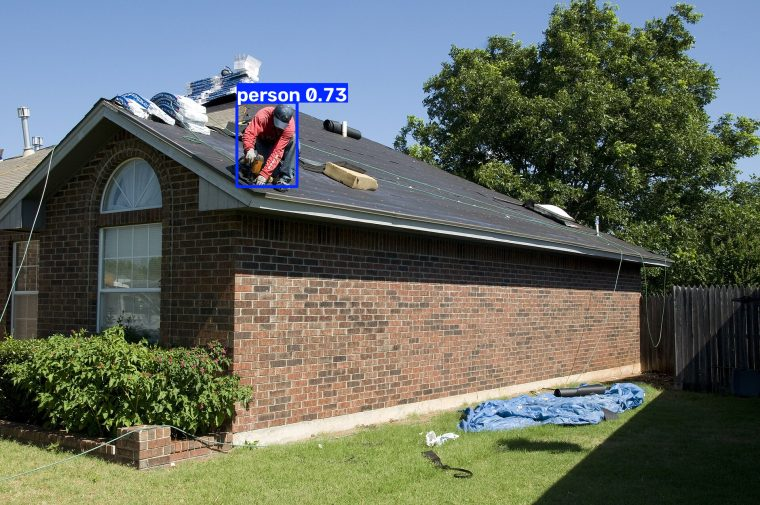

site_01.jpg
  boxes tensor shape (N, 6) : (2, 6)
  detections                : 2  (persons: 2)
  classes seen              : ['person']
--- detection: site_01.jpg ---


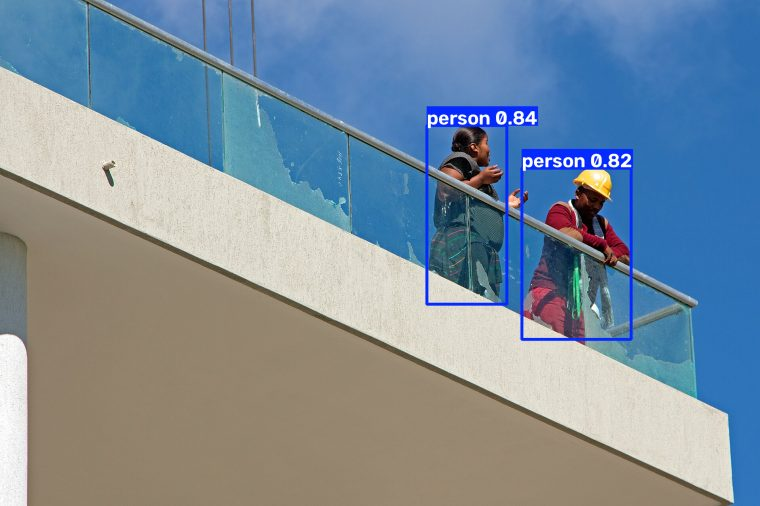

site_03.jpg
  boxes tensor shape (N, 6) : (5, 6)
  detections                : 5  (persons: 2)
  classes seen              : ['car', 'person']
--- detection: site_03.jpg ---


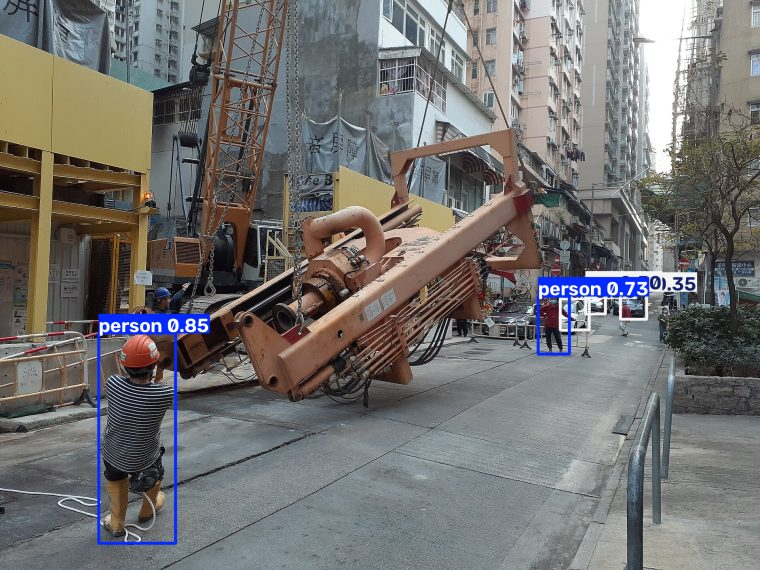

In [4]:
detector = YOLO("yolo11n.pt")

SHOWCASE = ["site_07.jpg", "site_01.jpg", "site_03.jpg"]
det_results = {}

for name in SHOWCASE:
    path = ROOT / "data" / "images" / name
    result = detector.predict(source=str(path), conf=0.25, verbose=False)[0]
    det_results[name] = result

    people = [b for b in result.boxes if result.names[int(b.cls)] == "person"]
    print(f"{name}")
    print(f"  boxes tensor shape (N, 6) : {tuple(result.boxes.data.shape)}")
    print(f"  detections                : {len(result.boxes)}  (persons: {len(people)})")
    print(f"  classes seen              : {sorted({result.names[int(b.cls)] for b in result.boxes})}")

    annotated = result.plot()
    save_evidence(annotated, f"01_detect_{Path(name).stem}.jpg")
    show(annotated, title=f"--- detection: {name} ---")

### Reading the raw numbers, not just the picture

`.plot()` is convenient but hides the data. Everything downstream in this project — the
compliance ledger, the evidence crops — works off these tensors directly, so it is worth
unpacking one detection by hand.

class      : person
confidence : 0.7346
xyxy       : (598.6, 258.1) -> (750.2, 472.0)
xywh       : [674.4, 365.0, 151.7, 213.9]   (centre x, centre y, w, h)
xyxyn      : [0.3118, 0.2023, 0.3908, 0.3699]  (normalised 0-1)

image is 1920x1276; box covers 1.3% of the frame
crop shape : (213, 152, 3)  (h, w, c)
--- cropped worker ---


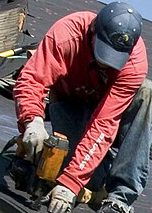

In [5]:
result = det_results["site_07.jpg"]
box = result.boxes[0]

x1, y1, x2, y2 = box.xyxy[0].tolist()
print(f"class      : {result.names[int(box.cls)]}")
print(f"confidence : {float(box.conf):.4f}")
print(f"xyxy       : ({x1:.1f}, {y1:.1f}) -> ({x2:.1f}, {y2:.1f})")
print(f"xywh       : {[round(v, 1) for v in box.xywh[0].tolist()]}   (centre x, centre y, w, h)")
print(f"xyxyn      : {[round(v, 4) for v in box.xyxyn[0].tolist()]}  (normalised 0-1)")

# Normalised coordinates are what training consumes: a worker occupying half the
# frame is w=0.5 whether the image is 4K or 720p. predict() un-normalises for us.
h, w = result.orig_shape
print(f"\nimage is {w}x{h}; box covers {100 * (x2 - x1) * (y2 - y1) / (w * h):.1f}% of the frame")

# Crop the worker out. NumPy is [row, col] = [y, x] while boxes are (x1, y1, x2, y2).
crop = result.orig_img[int(y1):int(y2), int(x1):int(x2)]
print(f"crop shape : {crop.shape}  (h, w, c)")
show(crop, max_w=300, title="--- cropped worker ---")

### Where the pre-trained detector fails

Worth recording now, because it motivates the whole rest of the project.

In [6]:
print(f"{'image':<14}{'persons':>9}   other COCO classes")
print("-" * 60)
for path in IMAGES:
    r = detector.predict(source=str(path), conf=0.25, verbose=False)[0]
    persons = [b for b in r.boxes if r.names[int(b.cls)] == "person"]
    other = sorted({r.names[int(b.cls)] for b in r.boxes if r.names[int(b.cls)] != "person"})
    print(f"{path.name:<14}{len(persons):>9}   {other}")

image           persons   other COCO classes
------------------------------------------------------------


site_01.jpg           2   []


site_02.jpg           1   ['bottle']


site_03.jpg           2   ['car']


site_04.jpg           0   []


site_05.jpg           0   []


site_06.jpg           2   []


site_07.jpg           1   []


site_08.jpg           0   ['dog']


Three failure modes visible in that table, all of which matter for a real deployment:

- **`site_04` / `site_05` — nothing found.** Wide crane shots where workers are a few dozen
  pixels tall. YOLO resizes the input to 640 px, so distant workers effectively vanish. The
  standard fix is [SAHI](https://docs.ultralytics.com/guides/sahi-tiled-inference/) tiled
  inference rather than retraining.
- **`site_08` — a welder classified as `dog`.** Heavy protective gear in an unusual crouched
  posture falls outside anything COCO contains.
- **No PPE anywhere.** COCO has `person`, and nothing else relevant. There is no `Hardhat`
  class, so *compliance cannot be assessed at all* with these weights — which is precisely the
  gap notebook 04 closes by fine-tuning on labelled construction-site data.

## 3. Instance segmentation — task beyond detection (1/2)

Same image, different head: `-seg` weights add a per-instance pixel mask on top of every box.
Masks come back as an `(N, H, W)` tensor plus polygon contours.

site_07.jpg
  masks tensor shape (N, H, W) : (2, 448, 640)
  polygon contours             : 2
  first polygon vertex count   : 82
  mask 0 covers 0.78% of the mask canvas


--- segmentation: site_07.jpg ---


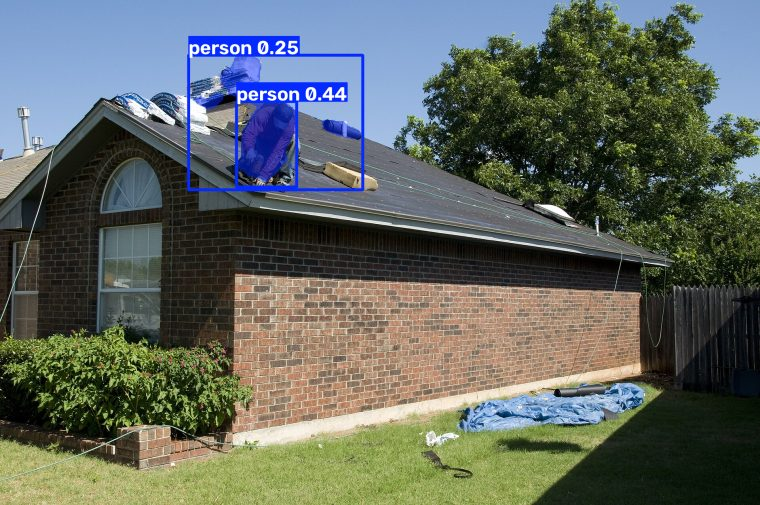

site_03.jpg
  masks tensor shape (N, H, W) : (4, 480, 640)
  polygon contours             : 4
  first polygon vertex count   : 168
  mask 0 covers 2.51% of the mask canvas


--- segmentation: site_03.jpg ---


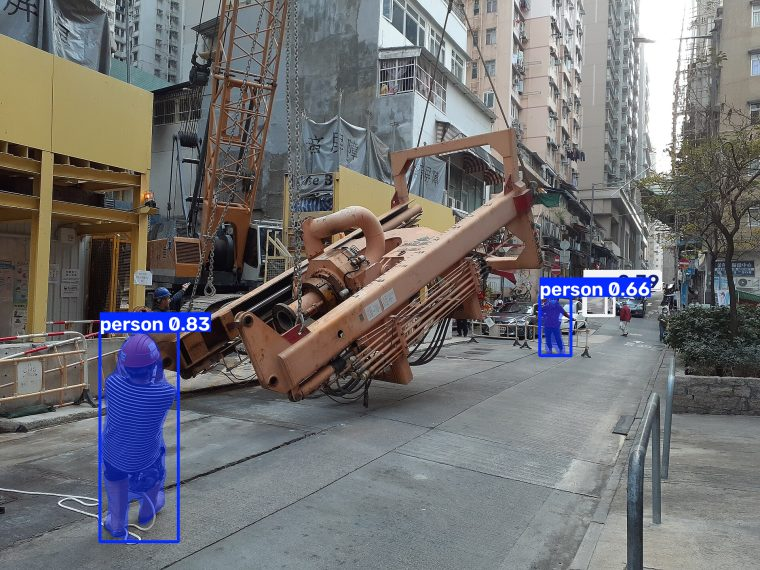

In [7]:
segmenter = YOLO("yolo11n-seg.pt")

for name in ["site_07.jpg", "site_03.jpg"]:
    path = ROOT / "data" / "images" / name
    result = segmenter.predict(source=str(path), conf=0.25, verbose=False)[0]

    print(f"{name}")
    if result.masks is not None:
        print(f"  masks tensor shape (N, H, W) : {tuple(result.masks.data.shape)}")
        print(f"  polygon contours             : {len(result.masks.xy)}")
        print(f"  first polygon vertex count   : {len(result.masks.xy[0])}")
        mask0 = result.masks.data[0].cpu().numpy()
        print(f"  mask 0 covers {100 * mask0.mean():.2f}% of the mask canvas")
    else:
        print("  no masks")

    annotated = result.plot()
    save_evidence(annotated, f"01_segment_{Path(name).stem}.jpg")
    show(annotated, title=f"--- segmentation: {name} ---")

**Why segmentation earns its place here.** A bounding box around a worker on a scaffold contains
a great deal of scaffold. A mask contains the worker. When the compliance ledger crops evidence,
and when a future version measures whether a hi-vis vest covers enough of the torso, pixel-level
extent is the difference between measuring a person and measuring the background behind them.

## 4. Pose estimation — task beyond detection (2/2)

`-pose` weights return `(N, 17, 3)`: 17 COCO keypoints per person, each `(x, y, confidence)`.

site_07.jpg
  keypoints tensor shape (N, 17, 3) : (1, 17, 3)
  person 0 — head keypoints:
    nose         (  726.8,   333.2)  conf=0.891  visible
    left_eye     (  728.0,   325.3)  conf=0.735  visible
    right_eye    (  722.4,   323.9)  conf=0.839  visible
    left_ear     (  720.6,   308.9)  conf=0.409  visible
    right_ear    (  711.6,   305.6)  conf=0.644  visible
--- pose: site_07.jpg ---


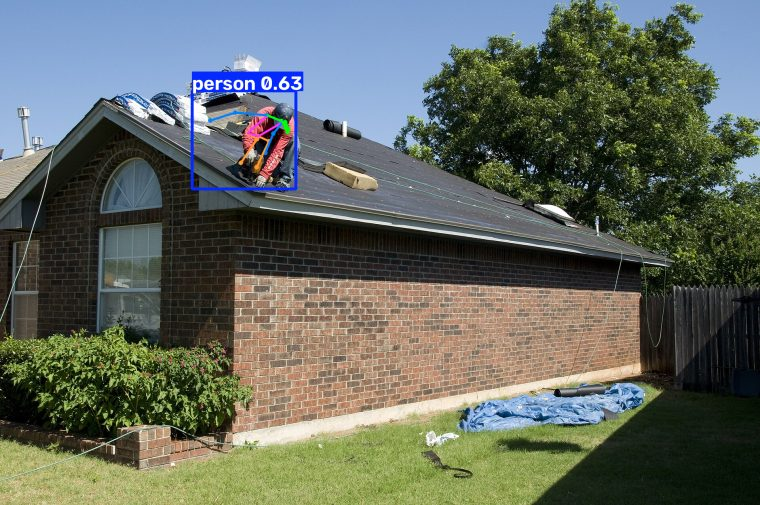

site_01.jpg
  keypoints tensor shape (N, 17, 3) : (2, 17, 3)
  person 0 — head keypoints:
    nose         ( 1506.6,   519.8)  conf=0.989  visible
    left_eye     ( 1519.7,   508.2)  conf=0.890  visible
    right_eye    ( 1497.4,   501.0)  conf=0.985  visible
    left_ear     ( 1529.2,   506.1)  conf=0.228  not visible
    right_ear    ( 1462.7,   484.8)  conf=0.930  visible
--- pose: site_01.jpg ---


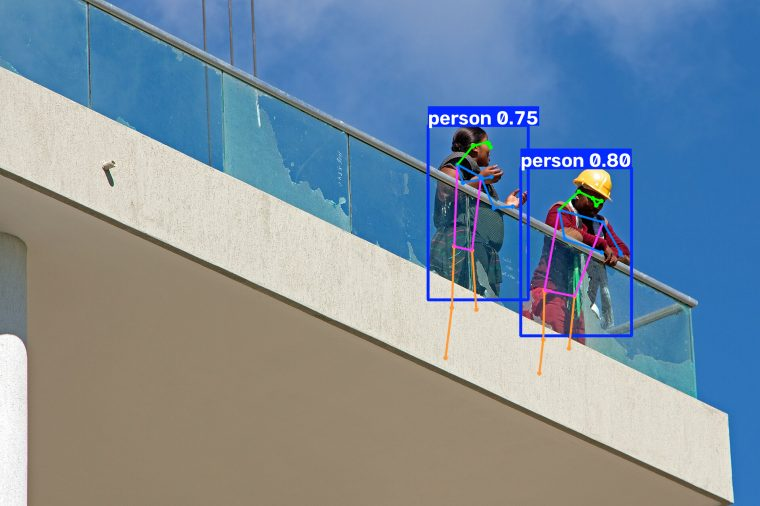

In [8]:
poser = YOLO("yolo11n-pose.pt")

COCO_KEYPOINTS = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]

pose_results = {}
for name in ["site_07.jpg", "site_01.jpg"]:
    path = ROOT / "data" / "images" / name
    result = poser.predict(source=str(path), conf=0.25, verbose=False)[0]
    pose_results[name] = result

    print(f"{name}")
    if result.keypoints is not None and len(result.keypoints):
        print(f"  keypoints tensor shape (N, 17, 3) : {tuple(result.keypoints.data.shape)}")
        kp = result.keypoints.data[0].cpu().numpy()
        print(f"  person 0 — head keypoints:")
        for i in range(5):
            x, y, c = kp[i]
            state = "visible" if c >= 0.3 else "not visible"
            print(f"    {COCO_KEYPOINTS[i]:<12} ({x:7.1f}, {y:7.1f})  conf={c:.3f}  {state}")
    else:
        print("  no people found")

    annotated = result.plot()
    save_evidence(annotated, f"01_pose_{Path(name).stem}.jpg")
    show(annotated, title=f"--- pose: {name} ---")

## 5. From keypoints to a head region — the bridge to PPE

COCO has no "head" class, but it has a nose, two eyes and two ears. A hard hat must sit
**above** those points. `ppe_monitor.video.head_roi_from_keypoints` turns the visible facial
keypoints into a rectangle covering the head, extending upward to include the helmet volume.

This is the region a helmet check has to look at, and it is derived geometrically — no extra
model, no extra training.

site_07.jpg: 1 person(s)
  person 0: head ROI (677, 252) -> (766, 352)   89x100 px


--- head ROIs: site_07.jpg ---


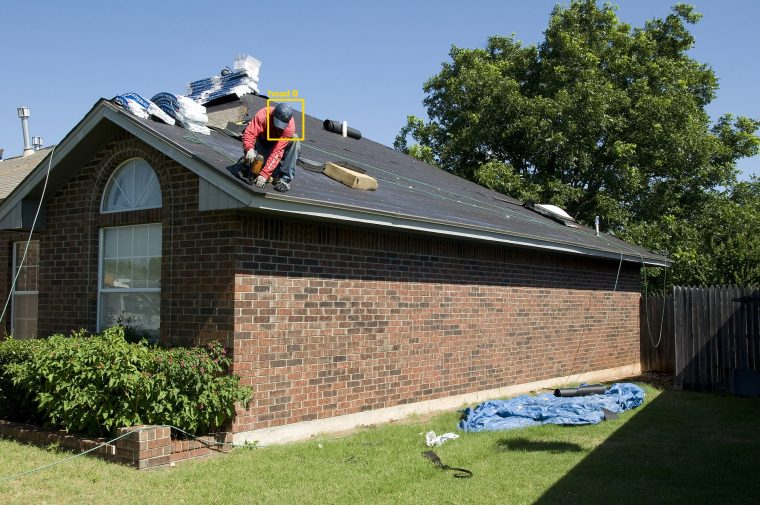

head regions, isolated:


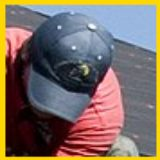

site_01.jpg: 2 person(s)
  person 0: head ROI (1405, 366) -> (1587, 571)   182x205 px
  person 1: head ROI (1151, 261) -> (1292, 420)   141x159 px
--- head ROIs: site_01.jpg ---


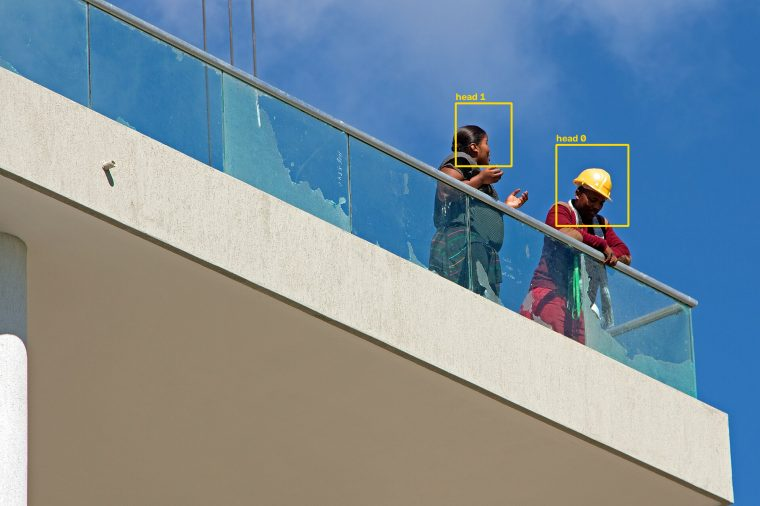

head regions, isolated:


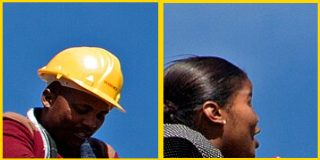

In [9]:
from ppe_monitor.video import head_roi_from_keypoints

for name, result in pose_results.items():
    if result.keypoints is None or not len(result.keypoints):
        continue

    canvas = result.orig_img.copy()
    kpts_all = result.keypoints.data.cpu().numpy()
    crops = []

    print(f"{name}: {len(kpts_all)} person(s)")
    for i, kpts in enumerate(kpts_all):
        roi = head_roi_from_keypoints(kpts, canvas.shape)
        if roi is None:
            print(f"  person {i}: head ROI unavailable (fewer than 2 facial keypoints visible)")
            continue
        x1, y1, x2, y2 = roi
        print(f"  person {i}: head ROI ({x1}, {y1}) -> ({x2}, {y2})   {x2 - x1}x{y2 - y1} px")
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 215, 255), 3)
        cv2.putText(canvas, f"head {i}", (x1, max(0, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 215, 255), 2)
        crop = canvas[y1:y2, x1:x2]           # [row, col] = [y, x]
        if crop.size:
            crops.append(cv2.resize(crop, (160, 160)))

    save_evidence(canvas, f"01_headroi_{Path(name).stem}.jpg")
    show(canvas, title=f"--- head ROIs: {name} ---")
    if crops:
        show(np.hstack(crops), max_w=160 * len(crops), title="head regions, isolated:")

Those crops are where a helmet either is or is not. Note the honest limitation: the ROI only
exists when the face is visible. A worker photographed from behind — common on a real site —
has no visible facial keypoints and yields no ROI. That is a good argument for detecting
`Hardhat` / `NO-Hardhat` directly as trained classes, which is exactly what the custom model in
notebook 04 does, with pose as a corroborating signal rather than the primary one.

## Summary

**Deliverable 1 evidence, all captured above:**

- `yolo` **CLI** — `task=detect mode=predict`, real output above
- **Detection** via the Python API — `(N, 6)` boxes, raw `xyxy` / `xywh` / normalised access,
  manual crop
- **Instance segmentation** with `yolo11n-seg.pt` — `(N, H, W)` masks and polygon contours
- **Pose estimation** with `yolo11n-pose.pt` — `(N, 17, 3)` keypoints
- **Applied**: head ROIs derived from facial keypoints, the region a hard hat must occupy

Annotated results are written to `outputs/01_*.jpg`.

**What this establishes:** off-the-shelf COCO weights find workers reliably when they are large
in frame, and are useless for PPE compliance because the classes simply do not exist. That is
the gap the rest of the project closes.

**Next:** [`02_video_analytics.ipynb`](02_video_analytics.ipynb) — tracking, entrance counting,
heatmaps and the violation ledger over real site video.